## Tracking

The notebook is supplementary to `analysisScripts/tracks.py`. Here we just investigate what is done in the `tracks.py` step by step.

In [1]:
from ipython_tools import handler

handler.style()

Welcome to JupyROOT 6.26/14


In [2]:
import glob
import math
import os
import sys
import time
from array import array

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ROOT as root
import scipy.special
import uproot
from scipy.integrate import quad
from scipy.optimize import curve_fit

In [3]:
import src.custom_functions as cf

In [4]:
%matplotlib inline

In [5]:
ntuple_file = "mixed/mixed_ntuple.root"
ntuple_file = uproot.open(
    ntuple_file
)  # uproot: investigate the contents of root file with uproot.

In [6]:
# list of contents with keys
ntuple_file.keys()

['pions;1', 'MCpions;1']

In [7]:
# names of classes without reading the objects
ntuple_file.classnames()

{'pions;1': 'TTree', 'MCpions;1': 'TTree'}

In [8]:
# get TTrees with square brackets
t_MCpions = ntuple_file["MCpions"]
t_pions = ntuple_file["pions"]

In [9]:
# t_pions.keys()
# t_pions.values()
# t_pions.typenames()
# t_pions.show()

In [10]:
# single TBranch in a TTree
# t_pions["px"].array()              # Awkward array (default)
# t_pions["px"].array(library="np")  # NumPy ndarray
# t_pions["px"].array(library="pd")  # Pandas series

In [11]:
# mom = t_pions.arrays(["px", "py", "pz"], library="pd")
# mom.head()

In [12]:
# get TTrees as DataFrames
MCpions = t_MCpions.arrays(library="pd")
pions = t_pions.arrays(library="pd")

- _Definition of variables not stored in the DataFrame (nTuples)_

In [13]:
MCpions.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__eventType__', '__weight__',
       'mcPX', 'mcPY', 'mcPZ', 'mcX', 'mcY', 'mcZ', 'mcPDG', 'isPrimarySignal',
       'seenInCDC', 'seenInSVD'],
      dtype='object')

In [14]:
MCpions["isPrimarySignal"].unique()

array([1., 0.])

In [15]:
MCpions["seenInCDC"].unique()

array([1., 0.])

In [16]:
pions.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__eventType__', '__weight__',
       'mcPX', 'mcPY', 'mcPZ', 'mcX', 'mcY', 'mcZ', 'mcPDG', 'px', 'py', 'pz',
       'x', 'y', 'z', 'isPrimarySignal', 'seenInCDC', 'seenInSVD', 'isSignal',
       'mcSecPhysProc', 'isCloneTrack', 'isTrackFlippedAndRefitted', 'charge'],
      dtype='object')

In [17]:
pions["isSignal"].unique()

array([ 1.,  0., nan])

In [18]:
pions["isPrimarySignal"].unique()

array([1., 0.])

In [19]:
pions["mcSecPhysProc"].unique()

array([  0.,  13., 121., 201.,  nan,  14., 151., 111.,   2.])

In [20]:
pions["isCloneTrack"].unique()

array([ 0.,  1., nan])

In [21]:
pions["isTrackFlippedAndRefitted"].unique()

array([0., 1.])

### _Derived Variables_

In [22]:
# new variables to MCpions DataFrame
MCpions["mcP"] = cf.p(MCpions["mcPX"], MCpions["mcPY"], MCpions["mcPZ"])
MCpions["mcPT"] = cf.pt(MCpions["mcPX"], MCpions["mcPY"])
MCpions["mcCosTheta"] = cf.costheta(MCpions["mcPX"], MCpions["mcPY"], MCpions["mcPZ"])
MCpions["mcPhi"] = cf.phi(MCpions["mcPX"], MCpions["mcPY"])

In [23]:
# new variables to pions DataFrame
pions["p"] = cf.p(pions["px"], pions["py"], pions["pz"])
pions["pt"] = cf.pt(pions["px"], pions["py"])
pions["cosTheta"] = cf.costheta(pions["px"], pions["py"], pions["pz"])
pions["phi"] = cf.phi(pions["px"], pions["py"])

pions["mcP"] = cf.p(pions["mcPX"], pions["mcPY"], pions["mcPZ"])
pions["mcPT"] = cf.pt(pions["mcPX"], pions["mcPY"])
pions["mcCosTheta"] = cf.costheta(pions["mcPX"], pions["mcPY"], pions["mcPZ"])
pions["mcPhi"] = cf.phi(pions["mcPX"], pions["mcPY"])

## FOMs


- Finding charge efficiency = $\frac{\text{matched MC with correct charge}}{\text{all primary MC}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch}}}{\text{MCpions}_{\text{tightMatch}}}$

- Finding efficiency = $\frac{\text{matched MC}}{\text{all primary MC}} \Leftrightarrow \frac{\text{pions}_{\text{looseMatch}}}{\text{MCpions}_{\text{tightMatch}}}$

- Charge efficiency = $\frac{\text{matched MC with correct charge}}{\text{matched MC}}  \Leftrightarrow \frac{\text{pions}_{\text{tightMatch}}}{\text{pions}_{\text{looseMatch}}}$

- Charge asymmetry = $\frac{\text{matched}^+ \text{ with correct charge} - \text{matched}^- \text{ with correct charge}}{\text{matched}^+ \text{ with correct charge} + \text{matched}^- \text{ with correct charge}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, plus}} - \text{pions}_{\text{tightMatch, minus}}}{\text{pions}_{\text{tightMatch, plus}} + \text{pions}_{\text{tightMatch, minus}}}$

- Fake rate = $\frac{\text{PR not related to MC}}{\text{all PR}} \Leftrightarrow \frac{\text{pions}_{\text{fake}}}{\text{pions}}$

- Clone rate = $\frac{\text{clones}}{\text{PR related to MC}} \Leftrightarrow \frac{\text{pions}_{\text{clone}}}{\text{pions}_{\text{wRelationToMC}}}$

- Flip Right = $\frac{\text{matched MC with correct charge} \land (\text{isTrackFlippedAndRefitted} = 1)}{(\text{isTrackFlippedAndRefitted} = 1) \land \text{matched MC}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, flipRefit}}}{\text{pions}_{\text{looseMatch, flipRefit}}}$

- Flip Wrong = $\frac{\text{matched MC with wrong charge} \land (\text{isTrackFlippedAndRefitted} = 1)}{(\text{isTrackFlippedAndRefitted} = 1) \land \text{matched MC}} \Leftrightarrow \frac{\text{pions}_{\text{wrongMatch, flipRefit}}}{\text{pions}_{\text{looseMatch, flipRefit}}}$

- Flipping efficiency = $\frac{\text{matched MC with correct charge} \land (\text{isTrackFlippedAndRefitted} = 1)}{[(\text{isTrackFlippedAndRefitted} = 1) \land \text{matched MC}] \lor \text{matched MC with wrong charge}} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, flipRefit}}}{(\text{pions}_{\text{looseMatch, flipRefit}}) \lor (\text{pions}_{\text{wrongMatch}})} \Leftrightarrow \frac{\text{pions}_{\text{tightMatch, flipRefit}}}{\text{pions}_{\text{toBeFlipped}}}$

- Flipped fraction = $\frac{\text{isTrackFlippedAndRefitted} = 1}{\text{all PR}} \Leftrightarrow \frac{\text{pions}_{\text{flipRefit}}}{\text{pions}}$

### Definition of Lists used for FOMs

- _**For MC Pions**_

In [24]:
MCpions_tightMatch = MCpions.query("isPrimarySignal==1")
MCpions_tightMatch_plus = MCpions.query("isPrimarySignal==1 and mcPDG == 211")
MCpions_tightMatch_minus = MCpions.query("isPrimarySignal==1 and mcPDG == -211")

- _**For Reco Pions**_

In [25]:
pions_tightMatch = pions.query("isPrimarySignal==1 and isCloneTrack==0")
pions_tightMatch_plus = pions_tightMatch.query("charge>0.")
pions_tightMatch_minus = pions_tightMatch.query("charge<0.")

In [26]:
pions_looseMatch = pions.query("abs(mcPDG)==211 and mcSecPhysProc==0 and (isSignal==0 or isSignal ==1) and isCloneTrack==0")
pions_wrongMatch = pions_looseMatch.query("isSignal == 0")

In [27]:
pions_fake = pions.query("isSignal!=0 and isSignal!=1")
pions_clone = pions.query("isCloneTrack==1")
pions_wRelationToMC = pions.query("isSignal==0 or isSignal==1")

In [28]:
pions_flipRefit = pions.query("isTrackFlippedAndRefitted==1")
pions_tigthMatch_flipRefit = pions_tightMatch.query("isTrackFlippedAndRefitted==1")

pions_tigthMatch_flipRefit_plus = pions_tightMatch_plus.query(
    "isTrackFlippedAndRefitted==1"
)
pions_tigthMatch_flipRefit_minus = pions_tightMatch_minus.query(
    "isTrackFlippedAndRefitted==1"
)

pions_looseMatch_flipRefit = pions_looseMatch.query("isTrackFlippedAndRefitted==1")
pions_wrongMatch_flipRefit = pions_wrongMatch.query("isTrackFlippedAndRefitted==1")

pions_toBeFlipped = pions_looseMatch.query(
    "isTrackFlippedAndRefitted==1 or isSignal == 0"
)

#### Same as above, with the additional requirement for track of being inside the detector acceptance  (seen in CDC or SVD) 
$\rightarrow$ These are actually the most interesting lists for pure tracking studies

In [45]:
# seen = "seenInSVD==1 or seenInCDC==1"
seen = "seenInCDC==1"

In [46]:
MCpions_tightMatch_seen = MCpions_tightMatch.query(seen)
MCpions_tightMatch_plus_seen = MCpions_tightMatch_plus.query(seen)
MCpions_tightMatch_minus_seen = MCpions_tightMatch_minus.query(seen)

In [47]:
pions_tightMatch_seen = pions_tightMatch.query(seen)
pions_tightMatch_plus_seen = pions_tightMatch_plus.query(seen)
pions_tightMatch_minus_seen = pions_tightMatch_minus.query(seen)

pions_looseMatch_seen = pions_looseMatch.query(seen)
pions_wrongMatch_seen = pions_wrongMatch.query(seen)

In [48]:

pions_clone_seen = pions_clone.query(seen)
pions_wRelationToMC_seen = pions_wRelationToMC.query(seen)
pions_flipRefit_seen = pions_flipRefit.query(seen)

In [49]:
pions_tigthMatch_flipRefit_seen = pions_tigthMatch_flipRefit.query(seen)
pions_tigthMatch_flipRefit_plus_seen = pions_tigthMatch_flipRefit_plus.query(seen)
pions_tigthMatch_flipRefit_minus_seen = pions_tigthMatch_flipRefit_minus.query(seen)

pions_looseMatch_flipRefit = pions_looseMatch_flipRefit.query(seen)
pions_wrongMatch_flipRefit = pions_wrongMatch_flipRefit.query(seen)

pions_toBeFlipped_seen = pions_toBeFlipped.query(seen)

## FOMs
- Finding charge efficiency = matched MC with correct charge / all primary MC 

- finding efficiency = matched MC / all primary MC                                                                                     

- charge efficiency = matched MC with correct charge / matched MC                                                                      

- charge asymmetry = (matched_plus with correct charge - matched_minus with correct charge) / (matched_plus with correct charge + matched_minus with correct charge) if (matched_plus + matched_minus) != 0 else 0.  

- fake rate = PR not related to MC / all PR                                                                                    

- clone rate = clones / PR related to MC                                                                                       

- flip right = (matched MC with correct charge && isTrackFlippedAndRefitted == 1) / (isTrackFlippedAndRefitted ==1 && matched MC)

- flip wrong = (matched MC with wrong charge && isTrackFlippedAndRefitted == 1) / (isTrackFlippedAndRefitted ==1 && matched MC) 

- flipping efficiency = (matched MC with correct charge && isTrackFlippedAndRefitted == 1) / ((isTrackFlippedAndRefitted ==1 && matched MC) || (matched MC with wrong charge))

- flipped fraction = isTrackFlippedAndRefitted == 1 / all PR

### Variables to be tested
- `x`: $cos\theta$
- `y`: $p$

<font color='red'> N.B.: for efficiency plots we need the MC information, while for asymmetries, fake rate, clone rate, flipping info we need the reconstructed information </font>

In [50]:
x_v, y_v = "mcCosTheta", "mcPT"
x_l, y_l = r"cos$\theta_{MC}$", "p$_{t,MC}$ [GeV/c]"
x_b = 6
y_b = [
    0.0,
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
    1.5,
    2.0,
]
x_r, y_r = (-1.5, 1.5), (0.0, 1.0)

In order to factor out the geometrical acceptance (= evaluate the pure tracking efficiency), use `_seen` lists as numerator and denominator in the efficiencies definitions

## Finding efficiency

- Mind the `seen` flag (in `tracking_metrics.py` the `seen` flag is `True`.

ratio (overall): 0.957686 +- 0.002359


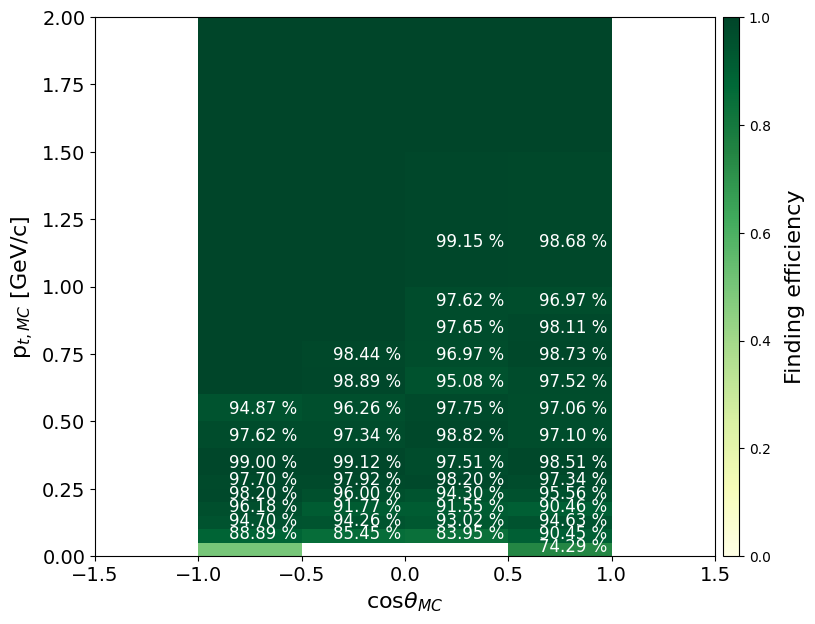

In [51]:
# finding efficiency
x, y, r, err_r, h_n1, h_n2, roverall, err_roverall, fig, pc = cf.ratio_2D(
        pions_looseMatch_seen,
        MCpions_tightMatch_seen,
        x_var=x_v,
        y_var=y_v,
        x_label=x_l,
        y_label=y_l,
        cbar_label="Finding efficiency",
        bins_x=x_b,
        bins_y=y_b,
        range_x=x_r,
        range_y=y_r,
        cmap="YlGn",
        vmin=0,
        vmax=1,
        color_text="white",
        color_text2="black",
        threshold=0.5,
        size_text=12,
        figsize=(8,7),
        savefig=True,
        figname="FE",
        savefigerr=True,
        errfigname="err_FE",
        offsetx=0.2,
        offsety=0.2,
        percent=True,
        closefig=False,
    )